# Support Vector Machines — A Beginner's Guide

This notebook builds up the **Support Vector Machine (SVM)** from first principles,
then extends the idea to its unsupervised cousin, the **One-Class SVM**, which is
used for novelty and outlier detection rather than classification.

By the end you should understand:

1. What a *maximal margin classifier* is, and why maximizing the margin is a good idea.
2. How the **hard-margin** and **soft-margin** SVM optimization problems are set up.
3. Why the **dual problem** and the **kernel trick** let SVMs learn non-linear boundaries.
4. How the **One-Class SVM** repurposes the same machinery to answer *"does this point
   look like it belongs to the training data?"* instead of *"which class is this?"*.
5. How to read the decision-boundary / margin / support-vector plots that accompany each idea.

We will use simulated 2D data throughout so that every decision boundary can be drawn
and interpreted directly — the same "see it, then trust it" approach used in the EWMA
control chart tutorial in this repository.

**Roadmap**

1. Setup
2. Why maximize the margin? The geometry of a linear classifier
3. The hard-margin SVM: an optimization problem
4. The soft-margin SVM: allowing some mistakes
5. The dual problem and support vectors
6. The kernel trick: non-linear boundaries
7. Effect of $C$ and the kernel bandwidth $\gamma$
8. One-Class SVM: classification without labels
9. Visualizing the One-Class SVM boundary
10. Comparing SVM and One-Class SVM
11. Summary and key takeaways

## 2. Setup

We fix a single random-number generator (`RNG`) that every simulation in this notebook
draws from, so all results are reproducible. We also set a shared plotting style and a
small named color palette used consistently in every figure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.svm import SVC, OneClassSVM
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.inspection import DecisionBoundaryDisplay

RNG = np.random.default_rng(seed=795)

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

COL_CLASS_A = "#1f77b4"   # class -1 / normal data points
COL_CLASS_B = "#d62728"   # class +1 / outliers
COL_BOUNDARY = "#2c2c2c"  # decision boundary line
COL_MARGIN = "#7f7f7f"    # margin lines
COL_SV = "#f2b134"        # support vector highlight

## 3. Why maximize the margin? The geometry of a linear classifier

Suppose we have labelled training points $(x_i, y_i)$, $i = 1, \dots, n$, where
$x_i \in \mathbb{R}^p$ are feature vectors and $y_i \in \{-1, +1\}$ are class labels.
If the two classes are linearly separable, there are infinitely many hyperplanes

$$w^\top x + b = 0$$

that separate them perfectly (any small rotation or shift of a valid separator is
usually still valid). Which one should we pick?

Intuitively, a boundary that passes very close to some training points is fragile: a
new point that is only slightly noisier than the training data could easily fall on
the wrong side. A boundary that keeps as much empty space as possible between itself
and *both* classes is more robust. This gap is called the **margin**, and the SVM is
exactly the classifier that **maximizes the margin**.

For a point $x_i$, the *functional margin* with respect to the hyperplane $(w, b)$ is
$y_i (w^\top x_i + b)$: positive when $x_i$ is correctly classified. Rescaling $w, b$
does not change the hyperplane itself, so we fix the scale by requiring the closest
points to satisfy $y_i(w^\top x_i + b) = 1$. The perpendicular (*geometric*) distance
from the hyperplane to such a point is then

$$\text{margin} = \frac{1}{\lVert w \rVert}.$$

The points that sit exactly on this boundary of the margin are the **support
vectors** — they are the only points that determine where the hyperplane sits; every
other point could be moved (without crossing the margin) and the solution would not
change. This is the key structural idea behind everything that follows.

In [2]:
# A small, perfectly linearly separable toy dataset, purely to illustrate the
# geometry: a hyperplane, its margin band, and the support vectors that define it.
X_geom, y_geom = make_blobs(
    n_samples=40, centers=[[-2, -2], [2, 2]], cluster_std=0.8,
    random_state=int(RNG.integers(0, 10_000)),
)
y_geom = np.where(y_geom == 0, -1, 1)

svm_geom = SVC(kernel="linear", C=1000)  # large C ~= hard margin
svm_geom.fit(X_geom, y_geom)

w = svm_geom.coef_[0]
b = svm_geom.intercept_[0]
margin_geom = 1 / np.linalg.norm(w)
print(f"||w|| = {np.linalg.norm(w):.3f}  ->  margin = 1/||w|| = {margin_geom:.3f}")
print(f"Number of support vectors: {svm_geom.support_vectors_.shape[0]}")

||w|| = 0.632  ->  margin = 1/||w|| = 1.581
Number of support vectors: 2


The cell below draws the fitted hyperplane $w^\top x + b = 0$ (solid line), the
two margin boundaries $w^\top x + b = \pm 1$ (dashed lines), and circles the support
vectors — the training points that lie exactly on the dashed lines. Notice that every
other point could be deleted from the training set without changing the fitted
boundary at all.

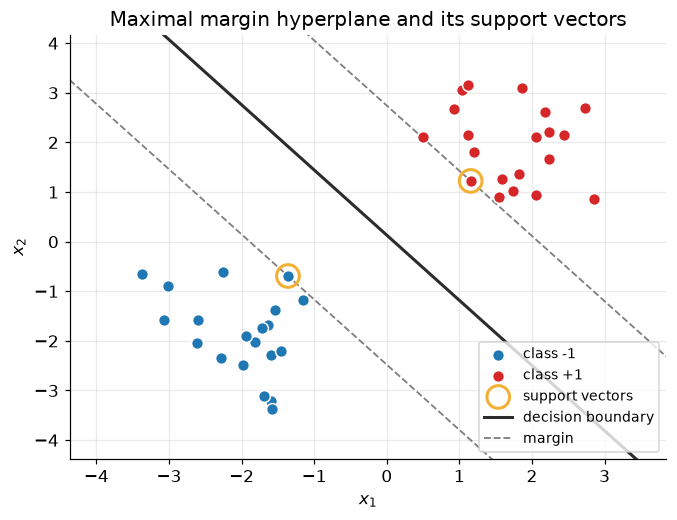

In [3]:
fig, ax = plt.subplots()

ax.scatter(X_geom[y_geom == -1, 0], X_geom[y_geom == -1, 1],
           c=COL_CLASS_A, label="class -1", edgecolor="white", s=60, zorder=3)
ax.scatter(X_geom[y_geom == 1, 0], X_geom[y_geom == 1, 1],
           c=COL_CLASS_B, label="class +1", edgecolor="white", s=60, zorder=3)

# Highlight support vectors with an open gold ring.
ax.scatter(svm_geom.support_vectors_[:, 0], svm_geom.support_vectors_[:, 1],
           facecolors="none", edgecolors=COL_SV, s=220, linewidths=2,
           label="support vectors", zorder=4)

xx = np.linspace(X_geom[:, 0].min() - 1, X_geom[:, 0].max() + 1, 200)
yy_boundary = -(w[0] * xx + b) / w[1]
yy_upper = -(w[0] * xx + b - 1) / w[1]
yy_lower = -(w[0] * xx + b + 1) / w[1]

ax.plot(xx, yy_boundary, color=COL_BOUNDARY, linewidth=2, label="decision boundary")
ax.plot(xx, yy_upper, "--", color=COL_MARGIN, linewidth=1.2, label="margin")
ax.plot(xx, yy_lower, "--", color=COL_MARGIN, linewidth=1.2)

ax.set_xlim(X_geom[:, 0].min() - 1, X_geom[:, 0].max() + 1)
ax.set_ylim(X_geom[:, 1].min() - 1, X_geom[:, 1].max() + 1)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Maximal margin hyperplane and its support vectors")
ax.legend(loc="lower right", fontsize=9)
plt.show()

## 4. The hard-margin SVM: an optimization problem

Fixing the scale so the closest points satisfy $y_i(w^\top x_i + b) = 1$, maximizing
the margin $1/\lVert w \rVert$ is the same as **minimizing** $\lVert w \rVert$, or
equivalently (and more conveniently, since it is differentiable and convex)
minimizing $\tfrac{1}{2}\lVert w \rVert^2$. This gives the **hard-margin SVM**
problem:

$$
\min_{w, b} \; \tfrac{1}{2} \lVert w \rVert^2
\quad \text{subject to} \quad
y_i (w^\top x_i + b) \geq 1, \quad i = 1, \dots, n.
$$

This is a convex quadratic program: a quadratic objective with linear inequality
constraints, which always has a unique global solution (when the classes are
separable). "Hard margin" refers to the fact that *every* training point must be
correctly classified and lie on or outside the margin — there is zero tolerance for
mistakes. This is precisely why hard-margin SVMs only make sense for linearly
separable data, and why we need the extension in the next section.

## 5. The soft-margin SVM: allowing some mistakes

Real data is rarely perfectly separable — classes overlap, and outliers exist. The
**soft-margin SVM** introduces a *slack variable* $\xi_i \geq 0$ for every point,
which measures how far that point violates its margin (zero if the point is correctly
placed beyond the margin, and positive otherwise):

$$
\min_{w, b, \xi} \; \tfrac{1}{2} \lVert w \rVert^2 + C \sum_{i=1}^n \xi_i
\quad \text{subject to} \quad
y_i (w^\top x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0, \quad i = 1, \dots, n.
$$

The term $\sum_i \xi_i$ is (up to scale) the **hinge loss**
$\sum_i \max(0,\, 1 - y_i(w^\top x_i + b))$: zero for points on the correct side of the
margin, and growing linearly for points that cross it.

$C > 0$ controls the trade-off between the two goals in the objective:

- **Large $C$**: violations are expensive, so the optimizer prioritizes classifying
  every training point correctly, even if that means a narrow margin (behaves close to
  the hard-margin case, and can overfit).
- **Small $C$**: violations are cheap, so the optimizer prefers a wide, "smoother"
  margin even if some points end up on the wrong side (more regularization, better
  robustness to noise, but can underfit).

We will see this trade-off directly in a plot in Section 7.

## 6. The dual problem and support vectors

The constrained optimization problems above are usually solved in their **Lagrangian
dual** form, for two reasons that matter a lot in practice: the dual depends on the
data *only* through inner products $x_i^\top x_j$ (which is what enables the kernel
trick in Section 7), and its solution directly identifies the support vectors.

Introducing Lagrange multipliers $\alpha_i \geq 0$ for the margin constraints, the dual
of the soft-margin problem is:

$$
\max_{\alpha} \; \sum_{i=1}^n \alpha_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n
\alpha_i \alpha_j \, y_i y_j \, x_i^\top x_j
\quad \text{subject to} \quad
0 \leq \alpha_i \leq C, \quad \sum_{i=1}^n \alpha_i y_i = 0.
$$

This is again a convex quadratic program, but now in $n$ variables $\alpha_i$ (one per
training point) instead of $p$ variables $w$ (one per feature) — convenient when there
are many features but few points, and essential for the kernel trick. The
**Karush-Kuhn-Tucker (KKT)** conditions of this problem show that at the optimum:

- $\alpha_i = 0$ for points safely outside the margin — they have *no influence* on the
  final boundary.
- $0 < \alpha_i < C$ for points exactly on the margin boundary.
- $\alpha_i = C$ for points that violate the margin (inside it, or misclassified).

Points with $\alpha_i > 0$ are exactly the **support vectors**: this is a precise,
algebraic restatement of the geometric picture from Section 3 — only points that touch
or cross the margin shape the decision boundary; the rest could be removed with no
effect on the fit. Once the optimal $\alpha_i$ are found, the weight vector is
recovered as $w = \sum_i \alpha_i y_i x_i$, and new points are classified by the sign
of $w^\top x + b$.

## 7. The kernel trick: non-linear boundaries

Many real datasets are not linearly separable in their original feature space, but
*can* become separable after mapping the features into a higher-dimensional space via
some function $\phi(x)$. Because the dual problem above only ever uses the data
through inner products $x_i^\top x_j$, we never need to compute $\phi(x)$ explicitly —
we only need a **kernel function**

$$K(x_i, x_j) = \phi(x_i)^\top \phi(x_j)$$

that computes the inner product *in the mapped space* directly from the original
inputs. Substituting $K(x_i, x_j)$ for $x_i^\top x_j$ in the dual objective gives the
**kernelized SVM**, capable of learning non-linear boundaries while still solving a
convex quadratic program. Common choices include:

- **Linear**: $K(x_i, x_j) = x_i^\top x_j$ (no mapping — the boundary stays linear).
- **Polynomial** (degree $d$): $K(x_i, x_j) = (\gamma\, x_i^\top x_j + r)^d$.
- **Radial Basis Function (RBF / Gaussian)**:
  $K(x_i, x_j) = \exp\!\left(-\gamma \lVert x_i - x_j \rVert^2\right)$, $\gamma > 0$.

The RBF kernel is the most commonly used default: it measures similarity that decays
smoothly with distance, effectively giving every training point a local "zone of
influence" whose size is controlled by $\gamma$ (large $\gamma$ = narrow, tightly
fitted zones; small $\gamma$ = broad, smoother zones). We will use the RBF kernel for
the non-linear examples below, and revisit $\gamma$'s effect in Section 8.

The cell below fits a **linear** kernel SVM to a dataset that is not linearly
separable (two interleaving "moons"), then an **RBF** kernel SVM to the same data, so
you can see directly what the kernel trick buys us.

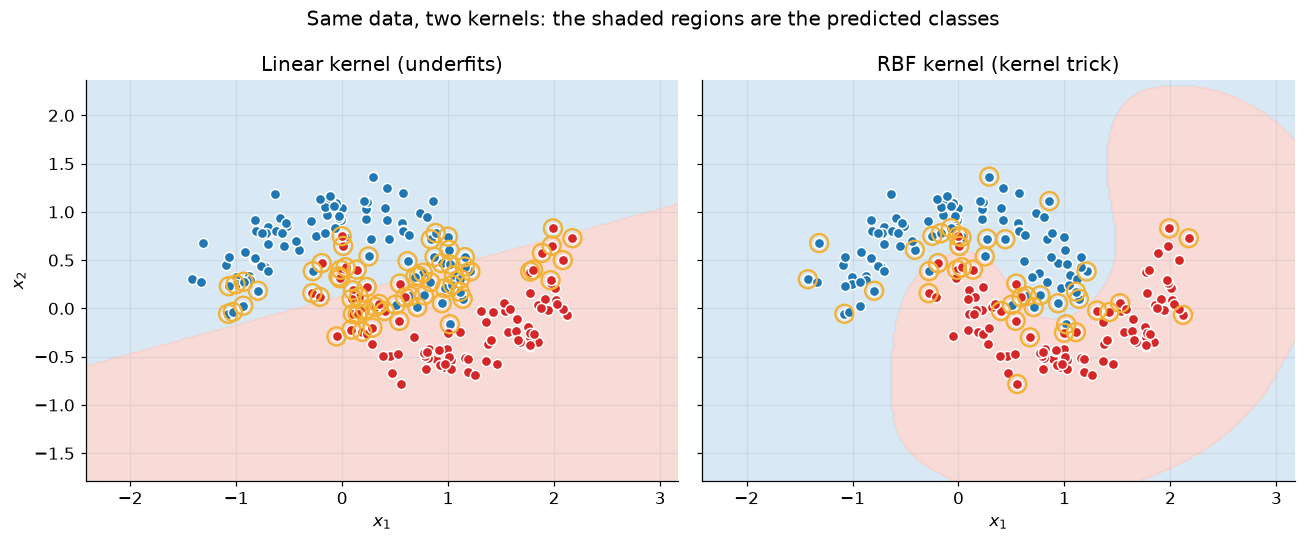

In [4]:
X_moons, y_moons = make_moons(
    n_samples=200, noise=0.2, random_state=int(RNG.integers(0, 10_000))
)
y_moons = np.where(y_moons == 0, -1, 1)

svm_linear = SVC(kernel="linear", C=1).fit(X_moons, y_moons)
svm_rbf = SVC(kernel="rbf", C=1, gamma=2.0).fit(X_moons, y_moons)

cmap_light = ListedColormap(["#cfe3f2", "#f7d3ce"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, model, title in zip(
    axes, [svm_linear, svm_rbf], ["Linear kernel (underfits)", "RBF kernel (kernel trick)"]
):
    DecisionBoundaryDisplay.from_estimator(
        model, X_moons, response_method="predict", cmap=cmap_light, alpha=0.8, ax=ax,
        grid_resolution=300,
    )
    ax.scatter(X_moons[y_moons == -1, 0], X_moons[y_moons == -1, 1],
               c=COL_CLASS_A, edgecolor="white", s=45, zorder=3)
    ax.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1],
               c=COL_CLASS_B, edgecolor="white", s=45, zorder=3)
    ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
               facecolors="none", edgecolors=COL_SV, s=140, linewidths=1.5, zorder=4)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")

axes[0].set_ylabel("$x_2$")
fig.suptitle("Same data, two kernels: the shaded regions are the predicted classes")
plt.tight_layout()
plt.show()

**Reading the plot:** the shaded background is the model's predicted class at
every point of the plane; the boundary between the two shades is the decision
boundary. The linear kernel (left) can only ever draw a straight line, so it cannot
separate two interleaved moons well — many points end up on the wrong side. The RBF
kernel (right) bends the boundary to follow the moon shapes, using every gold-circled
support vector to locally pull the boundary in the right direction. This is the kernel
trick in action: the boundary is non-linear in the original 2D space even though the
underlying optimization is still just a linear separator, in the (implicit,
never-computed) mapped feature space $\phi(x)$.

## 8. Effect of $C$ and the kernel bandwidth $\gamma$

Both hyperparameters trade off how tightly the model fits the training data:

- $C$ (Section 5) controls tolerance for margin violations.
- $\gamma$ (Section 7) controls how localized each point's influence is under the RBF
  kernel.

Small $C$ or small $\gamma$ push toward simpler, smoother boundaries (risk of
underfitting); large $C$ or large $\gamma$ push toward boundaries that hug the
training data tightly (risk of overfitting). The grid below fits an RBF-kernel SVM
across a $3\times3$ grid of $(C, \gamma)$ combinations on the same noisy, overlapping
dataset, so the effect of each parameter can be seen independently by scanning across
a row (fixed $\gamma$, varying $C$) or down a column (fixed $C$, varying $\gamma$).

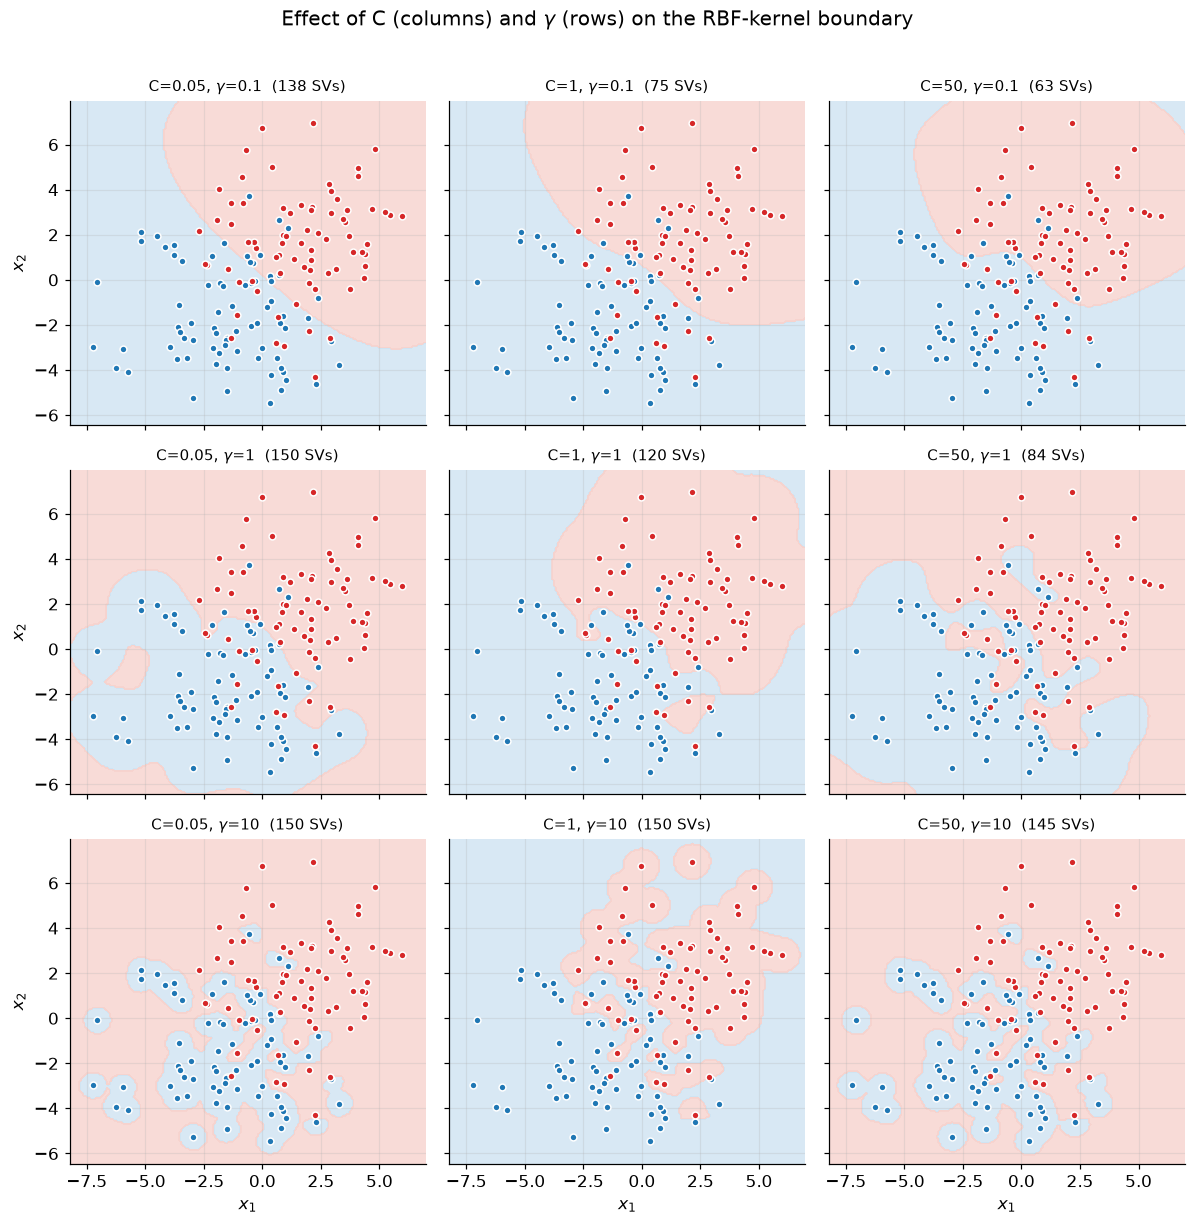

In [5]:
X_grid, y_grid = make_blobs(
    n_samples=150, centers=[[-1.5, -1.5], [1.5, 1.5]], cluster_std=2.2,
    random_state=int(RNG.integers(0, 10_000)),
)
y_grid = np.where(y_grid == 0, -1, 1)

C_values = [0.05, 1, 50]
gamma_values = [0.1, 1, 10]

fig, axes = plt.subplots(3, 3, figsize=(11, 11), sharex=True, sharey=True)

for i, gamma in enumerate(gamma_values):
    for j, C in enumerate(C_values):
        ax = axes[i, j]
        model = SVC(kernel="rbf", C=C, gamma=gamma).fit(X_grid, y_grid)
        DecisionBoundaryDisplay.from_estimator(
            model, X_grid, response_method="predict", cmap=cmap_light, alpha=0.8,
            ax=ax, grid_resolution=200,
        )
        ax.scatter(X_grid[y_grid == -1, 0], X_grid[y_grid == -1, 1],
                   c=COL_CLASS_A, edgecolor="white", s=20, zorder=3)
        ax.scatter(X_grid[y_grid == 1, 0], X_grid[y_grid == 1, 1],
                   c=COL_CLASS_B, edgecolor="white", s=20, zorder=3)
        n_sv = model.support_vectors_.shape[0]
        ax.set_title(f"C={C}, $\\gamma$={gamma}  ({n_sv} SVs)", fontsize=10)

for ax in axes[-1, :]:
    ax.set_xlabel("$x_1$")
for ax in axes[:, 0]:
    ax.set_ylabel("$x_2$")

fig.suptitle("Effect of C (columns) and $\\gamma$ (rows) on the RBF-kernel boundary", y=1.01)
plt.tight_layout()
plt.show()

**Reading the grid:** moving left to right (increasing $C$ at fixed $\gamma$),
the boundary becomes more willing to bend around individual points to reduce margin
violations. Moving top to bottom (increasing $\gamma$ at fixed $C$), each support
vector's zone of influence shrinks, so the boundary becomes increasingly wiggly and
localized — in the bottom row with $\gamma=10$, the model starts drawing tight
"islands" around individual points, a clear sign of overfitting. The number of support
vectors (shown in each subplot title) tends to grow as the boundary becomes more
complex: a smooth, simple boundary can be defined by a few points, but a wiggly one
needs many nearby points to constrain its shape. In practice, both $C$ and $\gamma$
are chosen by cross-validation rather than by eye.

## 9. One-Class SVM: classification without labels

Every SVM so far has needed labels $y_i \in \{-1, +1\}$ to separate two classes. But a
very common practical problem has **no negative examples at all**: you only have
examples of "normal" behaviour (e.g. non-fraudulent transactions, healthy sensor
readings, in-control process measurements) and want to flag *new* points that look
unlike anything seen before. This is **novelty detection** (assuming the training data
is clean) or **outlier detection** (if the training data may itself contain some
outliers), and the **One-Class SVM**, introduced by Schölkopf et al. (2001), adapts
the SVM machinery to solve it *without any labels*.

The idea: map the data into feature space via a kernel, as before, and find a
hyperplane that separates the *mapped* training points from the *origin* with maximum
margin. Any future point that maps too close to the origin (relative to this
hyperplane) is flagged as an outlier. Formally:

$$
\min_{w, \rho, \xi} \; \tfrac{1}{2}\lVert w \rVert^2 - \rho + \frac{1}{\nu n}
\sum_{i=1}^n \xi_i
\quad \text{subject to} \quad
w^\top \phi(x_i) \geq \rho - \xi_i, \quad \xi_i \geq 0, \quad i = 1, \dots, n.
$$

This has exactly the same shape as the soft-margin SVM problem in Section 5 — a norm
penalty plus a slack penalty — except there are no labels $y_i$, and instead of
separating two classes we are separating the data from the origin, with $\rho$ playing
the role that $b$ played before (the offset of the separating hyperplane). The decision
function for a new point $x$ is

$$
f(x) = \operatorname{sign}\!\left(w^\top \phi(x) - \rho\right),
$$

so $f(x) = +1$ marks $x$ as "normal" (inside the learned region) and $f(x) = -1$ marks
it as an outlier.

**The role of $\nu \in (0, 1]$.** This single parameter replaces $C$, and has a clean
dual interpretation proved alongside the original method:

- $\nu$ is an **upper bound** on the fraction of training points allowed to be
  outliers (i.e. to lie outside the learned boundary or violate their margin).
- $\nu$ is simultaneously a **lower bound** on the fraction of training points that
  become support vectors.

So $\nu$ directly sets your tolerance: $\nu = 0.05$ means "I expect roughly 5% of my
training data to be atypical, and I want the boundary to reflect that," producing a
tighter boundary than $\nu = 0.3$. This is usually far more intuitive to pick than $C$
was, because it is expressed as a fraction of the data rather than a raw penalty
weight.

## 10. Visualizing the One-Class SVM boundary

We simulate a single cluster of "normal" 2D points (no labels used during fitting) plus
a handful of scattered points that were **not** part of the cluster, to see whether the
model correctly separates them. We use the RBF kernel, so the learned region can wrap
around the cluster shape rather than being a simple ellipse.

In [6]:
X_normal, _ = make_blobs(
    n_samples=150, centers=[[0, 0]], cluster_std=1.0,
    random_state=int(RNG.integers(0, 10_000)),
)
# A handful of points scattered well away from the cluster, standing in for
# "novel" observations the model was never trained on.
X_novel = RNG.uniform(low=-6, high=6, size=(20, 2))

ocsvm = OneClassSVM(kernel="rbf", gamma=0.15, nu=0.05).fit(X_normal)

pred_train = ocsvm.predict(X_normal)   # +1 = normal, -1 = outlier
pred_novel = ocsvm.predict(X_novel)

frac_train_flagged = np.mean(pred_train == -1)
frac_novel_flagged = np.mean(pred_novel == -1)
print(f"nu = {ocsvm.nu} -> fraction of TRAINING points flagged as outliers: {frac_train_flagged:.2%}")
print(f"fraction of held-out scattered points flagged as outliers: {frac_novel_flagged:.2%}")

nu = 0.05 -> fraction of TRAINING points flagged as outliers: 6.00%
fraction of held-out scattered points flagged as outliers: 90.00%


With $\nu = 0.05$, we expect at most roughly 5% of the training data to fall
outside the learned boundary — the printed fraction above should be close to that.
Now let's plot the learned region directly: the decision function $f(x) = w^\top
\phi(x) - \rho$ is evaluated on a grid, and we shade where $f(x) \geq 0$ (predicted
"normal") versus $f(x) < 0$ (predicted "outlier"), with the $f(x) = 0$ contour drawn as
the boundary itself.

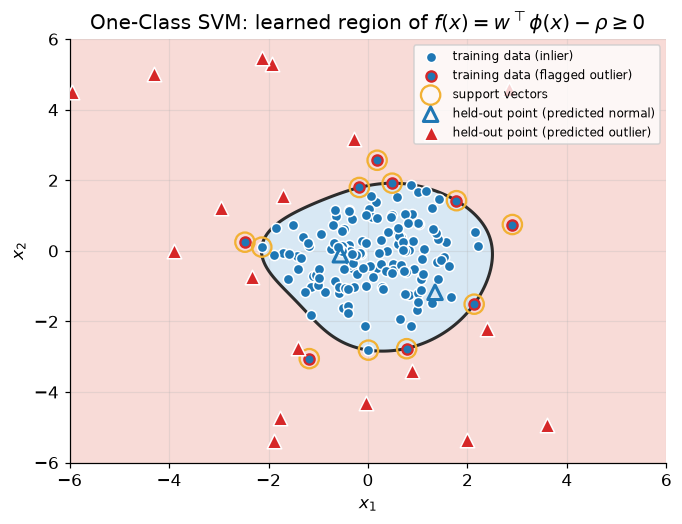

In [7]:
xx, yy = np.meshgrid(np.linspace(-6, 6, 300), np.linspace(-6, 6, 300))
Z = ocsvm.decision_function(np.column_stack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

fig, ax = plt.subplots()

ax.contourf(xx, yy, Z, levels=[Z.min(), 0, Z.max()],
            colors=["#f7d3ce", "#cfe3f2"], alpha=0.8)
ax.contour(xx, yy, Z, levels=[0], colors=[COL_BOUNDARY], linewidths=2)

ax.scatter(X_normal[pred_train == 1, 0], X_normal[pred_train == 1, 1],
           c=COL_CLASS_A, edgecolor="white", s=45, zorder=3, label="training data (inlier)")
ax.scatter(X_normal[pred_train == -1, 0], X_normal[pred_train == -1, 1],
           c=COL_CLASS_A, edgecolor=COL_CLASS_B, linewidths=1.5, s=45, zorder=3,
           label="training data (flagged outlier)")
ax.scatter(ocsvm.support_vectors_[:, 0], ocsvm.support_vectors_[:, 1],
           facecolors="none", edgecolors=COL_SV, s=160, linewidths=1.5, zorder=4,
           label="support vectors")
ax.scatter(X_novel[pred_novel == 1, 0], X_novel[pred_novel == 1, 1],
           marker="^", c="none", edgecolor=COL_CLASS_A, linewidths=2, s=90, zorder=5,
           label="held-out point (predicted normal)")
ax.scatter(X_novel[pred_novel == -1, 0], X_novel[pred_novel == -1, 1],
           marker="^", c=COL_CLASS_B, edgecolor="white", s=90, zorder=5,
           label="held-out point (predicted outlier)")

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(r"One-Class SVM: learned region of $f(x) = w^\top\phi(x) - \rho \geq 0$")
ax.legend(loc="upper right", fontsize=8)
plt.show()

**Reading the plot:** the blue shaded region is exactly the set of points the
model considers "normal" — everywhere the decision function is non-negative. The solid
contour line is the learned boundary $f(x) = 0$. Circular training points are the
original cluster; a handful are highlighted with a red outline because they happened
to land in the tail of the cluster and were flagged as outliers under $\nu = 0.05$
(exactly the small fraction $\nu$ promises). The gold-ringed points are the support
vectors — as with the two-class SVM, only these points (the ones on or near the
boundary) determine its shape. Finally, the triangular markers show the scattered
"held-out" points: those that landed inside the blue region are accepted as normal by
the model, while those landing in the shaded outlier region (outside the contour) are
correctly flagged, even though the model never saw a single labelled outlier during
training.

### 10.1 Effect of $\nu$ and $\gamma$ on the One-Class SVM boundary

Just like $C$ and $\gamma$ shaped the two-class boundary in Section 8, $\nu$ and
$\gamma$ shape the one-class boundary here. Larger $\nu$ allows (and expects) a larger
fraction of the training data to sit outside the boundary, shrinking the learned
region; larger $\gamma$ makes the boundary hug the training points more tightly,
potentially breaking one region into several disconnected "islands".

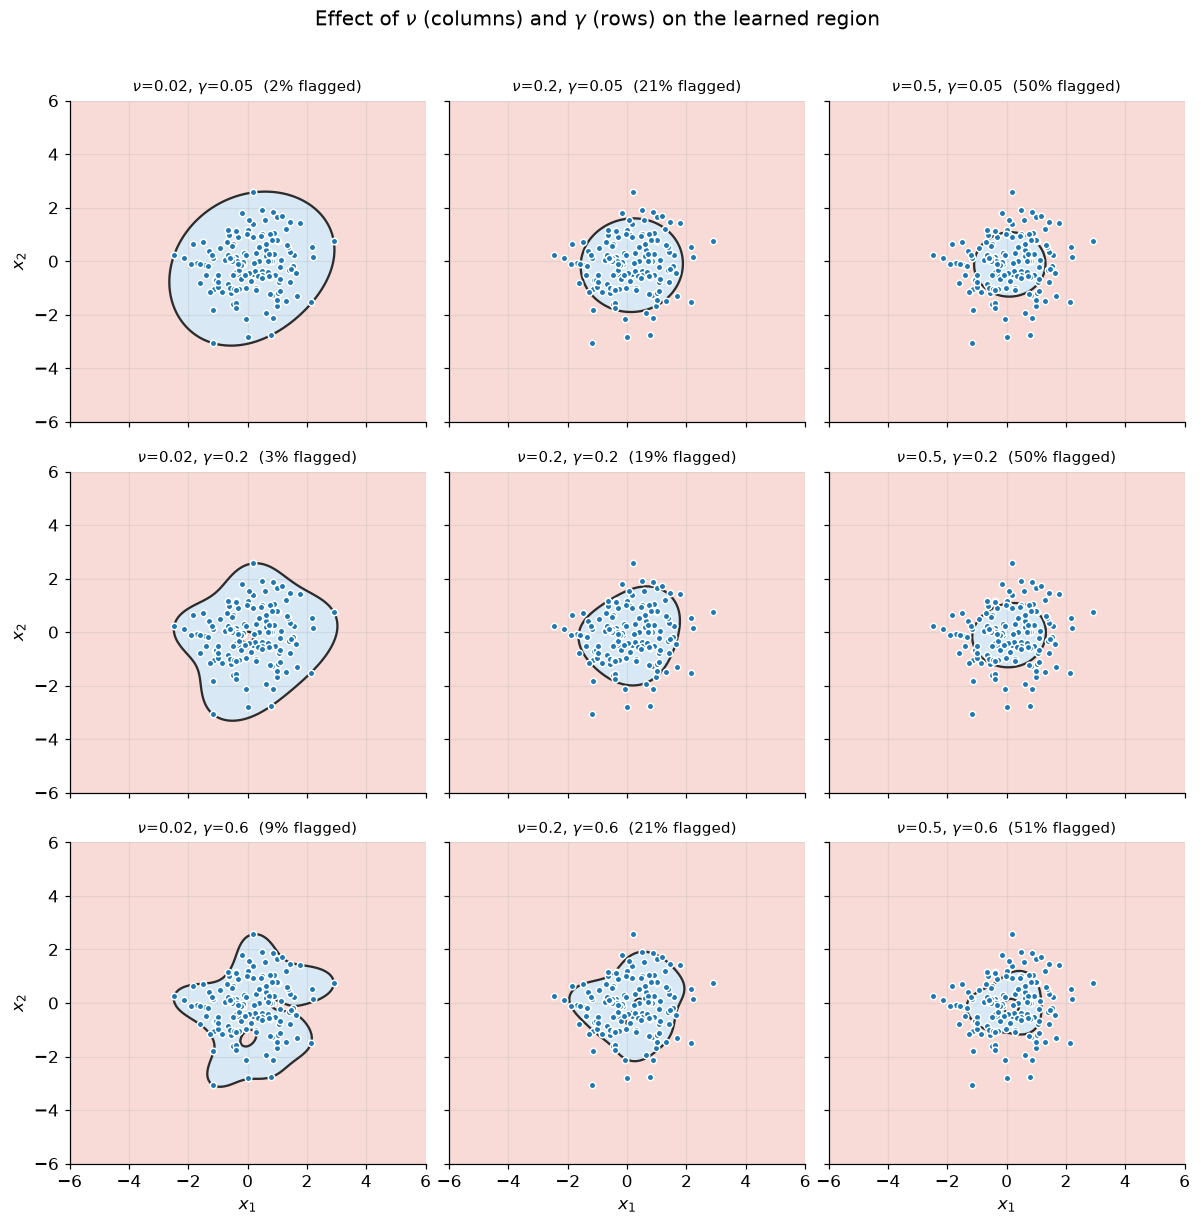

In [8]:
nu_values = [0.02, 0.2, 0.5]
gamma_values_oc = [0.05, 0.2, 0.6]

fig, axes = plt.subplots(3, 3, figsize=(11, 11), sharex=True, sharey=True)

for i, gamma in enumerate(gamma_values_oc):
    for j, nu in enumerate(nu_values):
        ax = axes[i, j]
        model = OneClassSVM(kernel="rbf", gamma=gamma, nu=nu).fit(X_normal)
        Zij = model.decision_function(
            np.column_stack([xx.ravel(), yy.ravel()])
        ).reshape(xx.shape)
        ax.contourf(xx, yy, Zij, levels=[Zij.min(), 0, Zij.max()],
                    colors=["#f7d3ce", "#cfe3f2"], alpha=0.8)
        ax.contour(xx, yy, Zij, levels=[0], colors=[COL_BOUNDARY], linewidths=1.5)
        ax.scatter(X_normal[:, 0], X_normal[:, 1], c=COL_CLASS_A, edgecolor="white",
                   s=18, zorder=3)
        frac_flagged = np.mean(model.predict(X_normal) == -1)
        ax.set_title(f"$\\nu$={nu}, $\\gamma$={gamma}  ({frac_flagged:.0%} flagged)",
                     fontsize=10)
        ax.set_xlim(-6, 6)
        ax.set_ylim(-6, 6)

for ax in axes[-1, :]:
    ax.set_xlabel("$x_1$")
for ax in axes[:, 0]:
    ax.set_ylabel("$x_2$")

fig.suptitle(r"Effect of $\nu$ (columns) and $\gamma$ (rows) on the learned region", y=1.01)
plt.tight_layout()
plt.show()

**Reading the grid:** moving left to right (increasing $\nu$ at fixed
$\gamma$), the model tolerates — and the boundary shrinks to produce — a larger
fraction of flagged training points, exactly as the theoretical upper bound predicts
(compare the "% flagged" annotation in each title to its column's $\nu$ value). Moving
top to bottom (increasing $\gamma$), the boundary transitions from a single smooth
blob to a tighter, more fragmented shape that follows the local density of points more
closely — at the highest $\gamma$ it can even split into separate islands around
denser sub-regions of the cluster. As with the two-class SVM, there is a bias-variance
trade-off: small $\gamma$ / small $\nu$ gives a smooth, possibly too permissive
boundary; large $\gamma$ / large $\nu$ gives a tight, possibly overfitted one.

*Note:* the $\nu$ bound is a guarantee about the optimizer's solution, not about the
predicted labels matching $\nu$ exactly on every dataset — at very large $\gamma$ the
boundary fragments so much that the observed "% flagged" can drift noticeably above
$\nu$, which is itself a useful signal that $\gamma$ has been pushed too high.

## 11. Comparing SVM and One-Class SVM

| | **SVM (classification)** | **One-Class SVM (novelty/outlier detection)** |
|---|---|---|
| Labels needed | Yes, $y_i \in \{-1, +1\}$ for every point | No labels at all |
| What is separated | Two classes from each other | Data from the origin (in feature space) |
| Key hyperparameter | $C$: cost of margin violations | $\nu$: expected fraction of outliers |
| Support vectors | Points on/inside the margin between classes | Points on/outside the learned boundary |
| Output | Predicted class ($-1$ or $+1$) | Normal ($+1$) vs. outlier ($-1$) |
| Typical use case | Spam vs. not-spam, disease vs. healthy (both known) | Fraud, sensor faults, defects — "have I seen this before?" |

Both are, underneath, the *same* convex optimization machinery: a quadratic
objective that trades off margin width against constraint violations, solved via a
dual problem expressed purely in terms of a kernel function, with the solution
sparsely supported by a small subset of the training points (the support vectors).
The One-Class SVM simply changes *what* is being separated — the data from the
origin, rather than one labelled class from another — which is what makes it usable
in the very common setting where labelled "bad" examples are rare, expensive, or
simply don't exist yet.

## 12. Summary and key takeaways

- An SVM finds the linear boundary that **maximizes the margin** between two classes,
  which tends to generalize better than an arbitrary separating boundary.
- The **hard-margin** formulation requires perfect separation; the **soft-margin**
  formulation introduces slack variables $\xi_i$ and a cost parameter $C$ to tolerate
  some violations, trading off margin width against training accuracy.
- The **dual problem** re-expresses the optimization in terms of Lagrange multipliers
  $\alpha_i$ and pairwise inner products $x_i^\top x_j$. Points with $\alpha_i > 0$ are
  the **support vectors** — the only points that determine the boundary.
- Because the dual only needs inner products, replacing $x_i^\top x_j$ with a
  **kernel function** $K(x_i, x_j)$ (the **kernel trick**) lets the SVM learn
  non-linear boundaries without ever explicitly computing the higher-dimensional
  feature map $\phi(x)$. The RBF kernel's bandwidth $\gamma$ and the cost $C$ jointly
  control the bias-variance trade-off of the fitted boundary.
- The **One-Class SVM** reuses the identical machinery to separate the training data
  from the origin in feature space, requiring **no labels**. Its parameter $\nu$ is an
  upper bound on the fraction of training points treated as outliers, and a lower
  bound on the fraction that become support vectors — making it directly usable for
  novelty and outlier detection.
- In both cases, only a small subset of the training data (the support vectors)
  determines the final model — the rest could be discarded without changing the fit,
  which is a large part of why SVMs remain effective even with limited data.